In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from umap import UMAP
import umap.plot
from sklearn.svm import SVC

/opt/homebrew/envs/datascience/lib/python3.11/site-packages/numba/np/ufunc/dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/opt/homebrew/envs/datascience/lib/python3.11/site-packages/numba/np/ufunc/dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/opt/homebrew/envs/datascience/lib/python3.11/site-packages/numba/np/ufunc/dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings

In [33]:
df = pd.read_parquet(
    '../data/cardiffnlp/twitter-roberta-base-sentiment-latest/embeddings_20260226_142645.parquet',
    engine='pyarrow'
)
print(f" Loaded {len(df)} samples")

 Loaded 4115 samples


In [10]:
df.head()

,sentiment,embedding
0,positive,"[0.04760853573679924, 0.09865032136440277, 0.1..."
1,neutral,"[-0.3224351704120636, -0.1342739462852478, -0...."
2,neutral,"[-0.22300809621810913, 0.36775514483451843, -0..."
3,negative,"[0.6130648255348206, -0.12749680876731873, 0.2..."
4,positive,"[-0.305381715297699, 0.22852210700511932, 0.28..."


In [11]:
# check column type counts
df['sentiment'].value_counts()

sentiment
neutral     2622
positive     754
negative     739
Name: count, dtype: int64

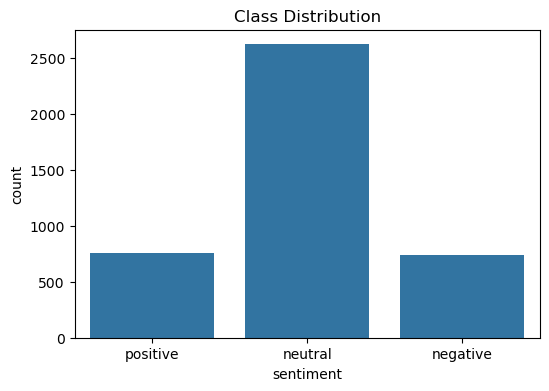

In [12]:
# class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df)
plt.title('Class Distribution')
plt.show()

### Manual Labels

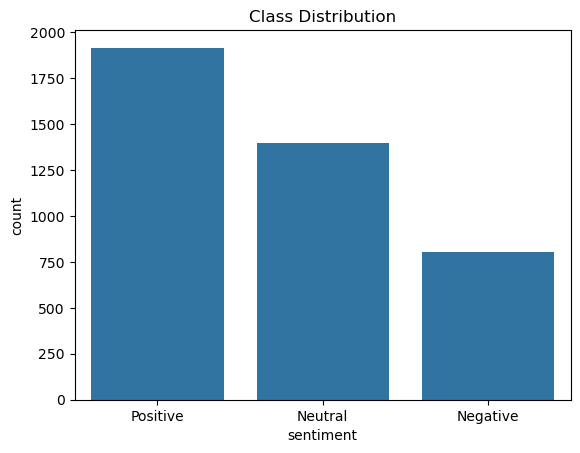

In [13]:
manual_labels = pd.read_csv('../data/10_cleaned_sentiments.csv')
print("Manual labels distribution:")
sns.countplot(x='sentiment', data=manual_labels)
plt.title('Class Distribution')
plt.show()

In [14]:
# accuracy
sentiment_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
df['sentiment'] = df['sentiment'].str.lower().map(sentiment_mapping)
manual_labels['sentiment'] = manual_labels['sentiment'].str.lower().map(sentiment_mapping)
print('Accuracy of model predictions on manually labeled data:')
accuracy = accuracy_score(manual_labels['sentiment'], df['sentiment'])
print(accuracy, '%')

Accuracy of model predictions on manually labeled data:
0.5292831105710815 %


In [20]:
# umap visualization
mapper_2d = UMAP(random_state=42, min_dist=0.3, n_neighbors=15)
mapper_2d = mapper_2d.fit(np.stack(df['embedding'].values))

/opt/homebrew/envs/datascience/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


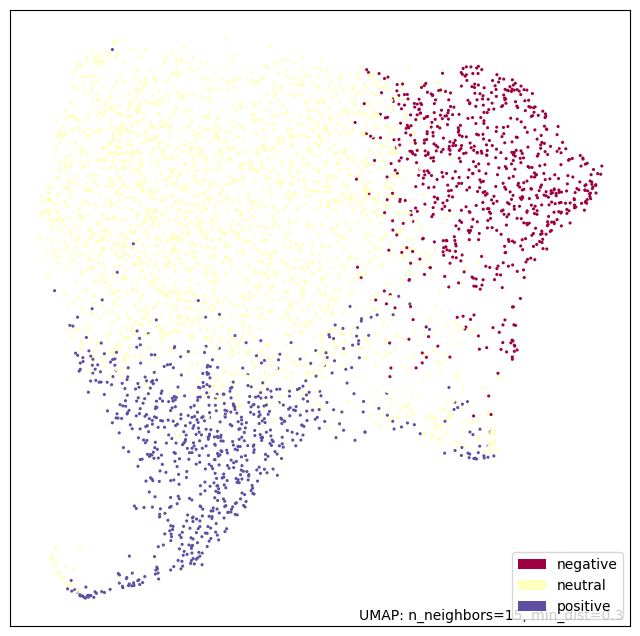

In [41]:
# plot
plot = umap.plot.points(mapper_2d, labels=df['sentiment'].values)
umap.plot.show(plot)

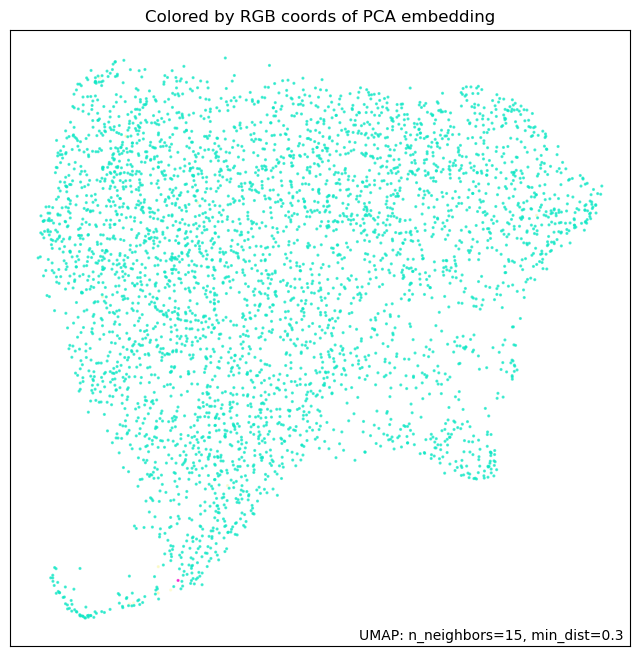

In [21]:
# diagnostics
plot = umap.plot.diagnostic(mapper_2d, diagnostic_type='pca')
umap.plot.show(plot)

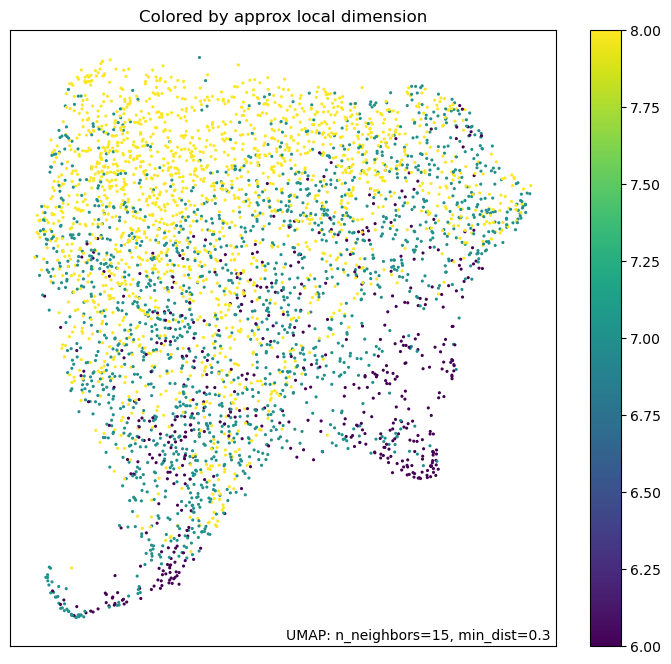

In [23]:
# local dim
plot = umap.plot.diagnostic(mapper_2d, diagnostic_type='local_dim')
umap.plot.show(plot)

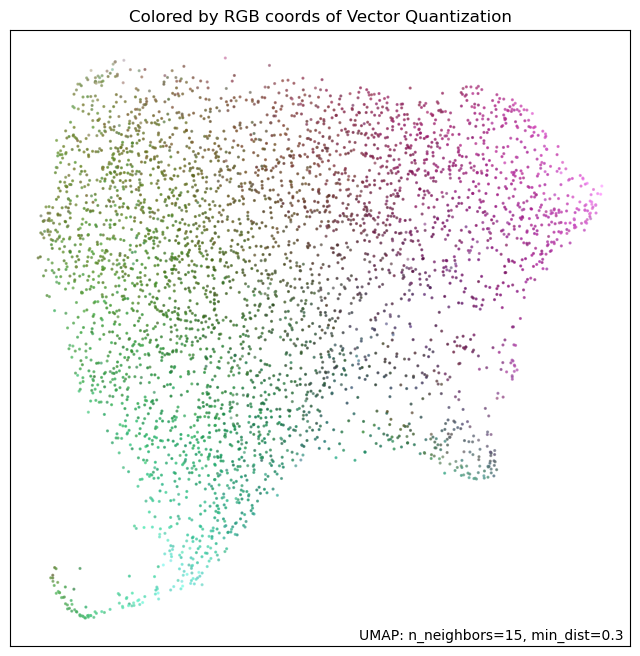

In [43]:
# local dim
plot = umap.plot.diagnostic(mapper_2d, diagnostic_type='vq')
umap.plot.show(plot)

In [28]:
# 3d
mapper_3d = UMAP(random_state=42,n_components=3)
mapper_3d = mapper_3d.fit_transform(np.stack(df['embedding'].values))

/opt/homebrew/envs/datascience/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


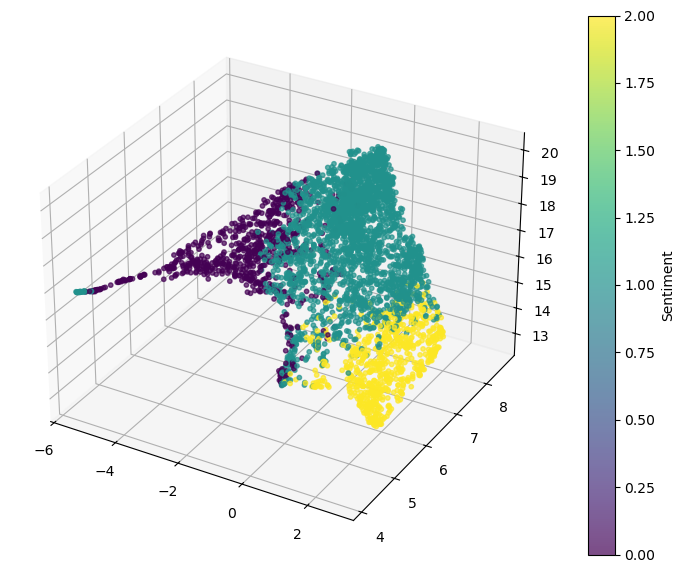

In [42]:
# plot with matplotlib
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(mapper_3d[:, 0], mapper_3d[:, 1], mapper_3d[:, 2], c=pd.factorize(df['sentiment'].values)[0], alpha=0.7, cmap='viridis', s=10)
plt.colorbar(scatter, ax=ax, label='Sentiment')
plt.show()

## Supervised UMAP

In [34]:
# relabel sentiments to integers for supervised UMAP
sentiment_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
df_relabelled = df.copy()
df_relabelled['sentiment'] = df_relabelled['sentiment'].map(sentiment_mapping)

In [35]:
# supervised UMAP
mapper_supervised = UMAP(random_state=42, n_neighbors=15, min_dist=0.3, n_components=2, metric='euclidean')
mapper_supervised = mapper_supervised.fit(np.stack(df_relabelled['embedding'].values), y=df_relabelled['sentiment'].values)

/opt/homebrew/envs/datascience/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


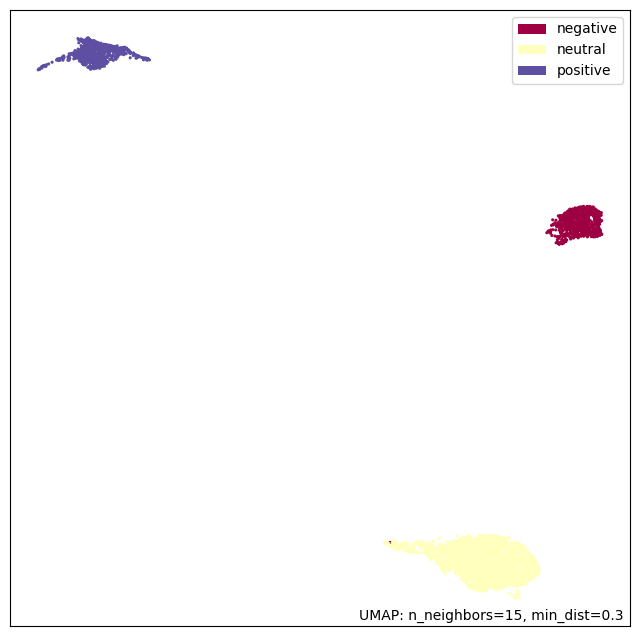

In [36]:
# plot results
plot = umap.plot.points(mapper_supervised, labels=df['sentiment'].values)
umap.plot.show(plot)

In [37]:
# diagnostics
plot = umap.plot.diagnostic(mapper_supervised, diagnostic_type='pca')
umap.plot.show(plot)

ValueError: array must not contain infs or NaNs

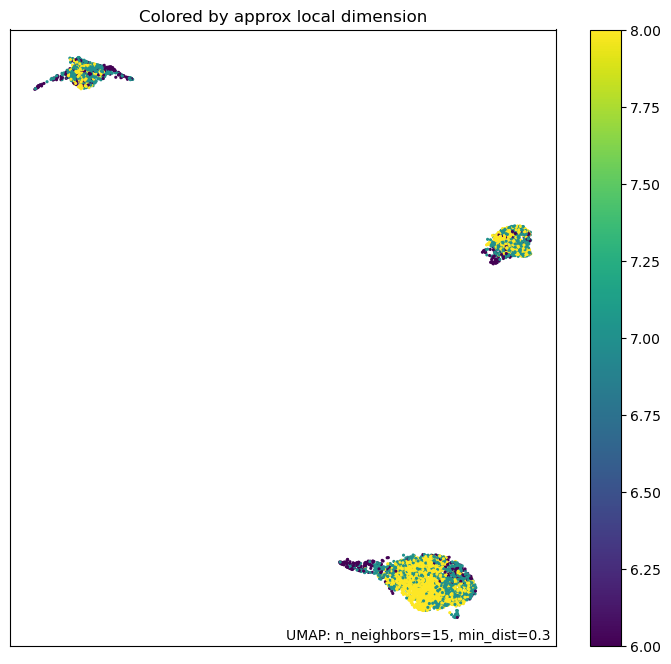

In [38]:
# local dim
plot = umap.plot.diagnostic(mapper_supervised, diagnostic_type='local_dim')
umap.plot.show(plot)

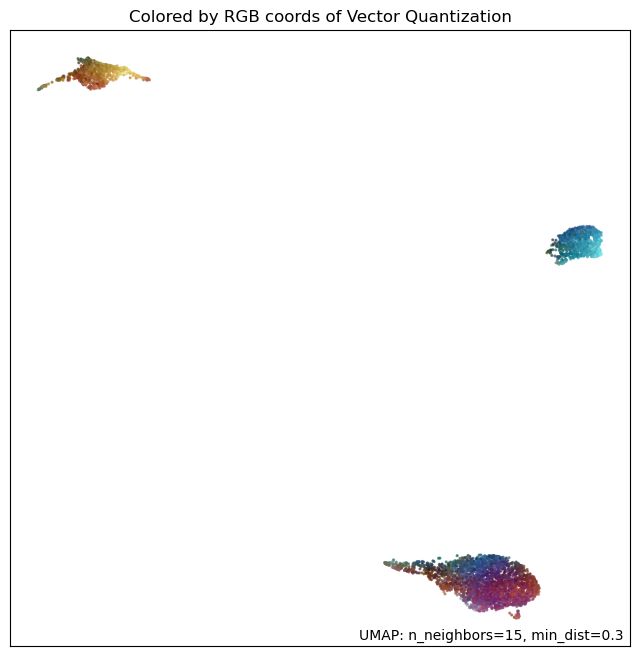

In [39]:
umap.plot.diagnostic(mapper_supervised, diagnostic_type='vq')
umap.plot.show(plot)

# Conclusion